In [27]:
import pandas as pd

In [28]:
df=pd.read_csv("../datasets/student_admission_500.csv")
df.head()

,Study_Hours,Attendance,Previous_Score,Entrance_Score,Admitted
0,2,75,82,52,Yes
1,10,58,56,87,Yes
2,8,61,46,58,No
3,6,97,69,79,Yes
4,6,63,79,66,Yes


In [29]:
x=df.drop(columns="Admitted")
x

,Study_Hours,Attendance,Previous_Score,Entrance_Score
0,2,75,82,52
1,10,58,56,87
2,8,61,46,58
3,6,97,69,79
4,6,63,79,66
...,...,...,...,...
495,5,84,68,47
496,2,84,75,63
497,5,60,75,54
498,12,54,87,66


<Axes: ylabel='Density'>

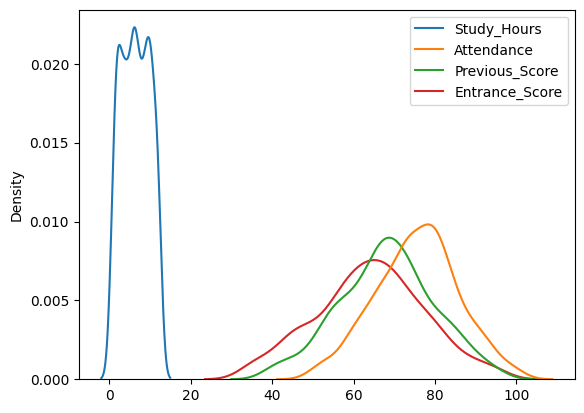

In [30]:
import seaborn as sns
sns.kdeplot(df)

In [31]:
y=df["Admitted"]
y

0      Yes
1      Yes
2       No
3      Yes
4      Yes
      ... 
495     No
496     No
497     No
498    Yes
499    Yes
Name: Admitted, Length: 500, dtype: str

In [32]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(x,y,random_state=87,test_size=0.2)

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor=ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            ["Study_Hours","Attendance","Previous_Score","Entrance_Score"]
        )
    ],remainder='passthrough'
).set_output(transform='pandas')

In [34]:
X_train_transformed=preprocessor.fit_transform(X_train)
X_train_transformed

,num__Study_Hours,num__Attendance,num__Previous_Score,num__Entrance_Score
12,0.735123,-0.946355,2.217526,0.341892
410,-1.013435,-0.147111,1.070492,1.304970
489,0.443697,0.452322,-0.605943,-0.028522
357,1.317976,0.252511,1.070492,1.601301
65,-0.722009,-0.247016,-0.164776,-0.917516
...,...,...,...,...
251,-0.139156,-0.247016,1.952826,-0.547102
143,-0.430582,-1.545788,-1.135343,-1.658345
187,-0.430582,-1.345977,-0.253009,0.712307
333,1.026549,0.252511,-0.958877,-1.362013


In [35]:
X_test_transformed=preprocessor.transform(X_test)
X_test_transformed

,num__Study_Hours,num__Attendance,num__Previous_Score,num__Entrance_Score
154,-0.139156,0.152606,1.158725,1.823550
227,0.152270,1.151661,0.982258,-1.362013
56,0.152270,-0.346922,1.158725,-0.621185
372,-0.430582,0.452322,-0.253009,0.119644
211,0.735123,2.050810,0.541091,-0.028522
...,...,...,...,...
313,-0.722009,-0.047205,-1.488277,-1.287931
412,-0.722009,-1.046260,-0.605943,-0.324853
280,-0.722009,-0.846449,0.364625,-2.176925
135,-0.722009,-0.147111,0.011691,0.564141


In [57]:
from sklearn.linear_model import LogisticRegression

model= LogisticRegression(random_state=20)

In [58]:
model.fit(X_train_transformed,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",20
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [59]:
y_pred=model.predict(X_test_transformed)

In [60]:
from sklearn.metrics import accuracy_score

accuracy=accuracy_score(y_pred,y_test)

In [61]:
accuracy

0.72

In [62]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_pred,y_test)


cm

array([[26, 12],
       [16, 46]])

In [63]:
from sklearn.metrics import classification_report

report=classification_report(y_test,y_pred,output_dict=True)

report_df=pd.DataFrame(report).T

report_df.round(3)

,precision,recall,f1-score,support
No,0.684,0.619,0.650,42.00
Yes,0.742,0.793,0.767,58.00
accuracy,0.720,0.720,0.720,0.72
macro avg,0.713,0.706,0.708,100.00
weighted avg,0.718,0.720,0.718,100.00
